# 1. Import Necessary Libraries

In [7]:
import tensorflow as tf
from tensorflow.keras.models import Model,Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape
import matplotlib.pyplot as plt
import numpy as np

# 2. Import Dataset

In [2]:
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

# 3. Data Preprocessing

In [3]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [8]:
input_img = Input(shape=(28,28,1))

# 4. Model Building

### 4.1 Encoder Block

In [9]:
encoder = Sequential()
encoder.add(tf.keras.Input(shape=(28,28,1)))
encoder.add(Flatten())
encoder.add(Dense(128, activation='relu'))
encoder.add(Dense(64, activation='relu'))
encoder.add(Dense(32, activation='relu')) # Bottleneck Layer - Main compressed representation

### 4.2 Decoder Block

In [10]:
decoder = Sequential()
decoder.add(tf.keras.Input(shape=(32,)))
decoder.add(Dense(64, activation='relu'))
decoder.add(Dense(128, activation='relu'))
decoder.add(Dense(784, activation='sigmoid'))
decoder.add(Reshape((28,28,1))) # Convert back to image

### 4.3 Combine to BUILD FULL AUTOENCODER

In [11]:
autoencoder = Sequential()
autoencoder.add(encoder)
autoencoder.add(decoder)

In [21]:
print("\n========== ENCODER ==========\n")
encoder.summary()
print("\n========== DECODER ==========\n")
decoder.summary()
print("\n========== AUTOENCODER ==========\n")
autoencoder.summary()


========== ENCODER ==========



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 110,816 (432.88 KB)

 Trainable params: 110,816 (432.88 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (None, 32)                  │         110,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_1 (Sequential)            │ (None, 28, 28, 1)           │         111,568 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 667,154 (2.54 MB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 444,770 (1.70 MB)

# 5. Model Compilation

In [13]:
autoencoder.compile(optimizer='adam',loss='mean_squared_error')

# 6. Model Training

In [14]:
history = autoencoder.fit(x_train, x_train, epochs=10, batch_size=256,validation_data=(x_test, x_test))

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0628 - val_loss: 0.0342
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0294 - val_loss: 0.0247
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0226 - val_loss: 0.0204
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0195 - val_loss: 0.0182
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0175 - val_loss: 0.0164
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0162 - val_loss: 0.0152
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0151 - val_loss: 0.0143
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0142 - val_loss: 0.0134
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0135 - val_loss: 0.0130
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0130 - val_loss: 0.0123


# 7. Model Prediction

### 7.1 SENDER SIDE - COMPRESS IMAGE

In [22]:
compressed_data = encoder.predict(x_test)

print("\n================================")
print("ORIGINAL DATA SHAPE :", x_test.shape)
print("COMPRESSED DATA SHAPE :", compressed_data.shape)
print("================================")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 953us/step

ORIGINAL DATA SHAPE : (10000, 28, 28)
COMPRESSED DATA SHAPE : (10000, 32)


In [23]:
print("\nSending compressed data through network...\n")
transmitted_data = compressed_data


Sending compressed data through network...



### RECEIVER SIDE - RECONSTRUCT IMAGE

In [24]:
reconstructed_images = decoder.predict(transmitted_data)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


## VISUALIZATION

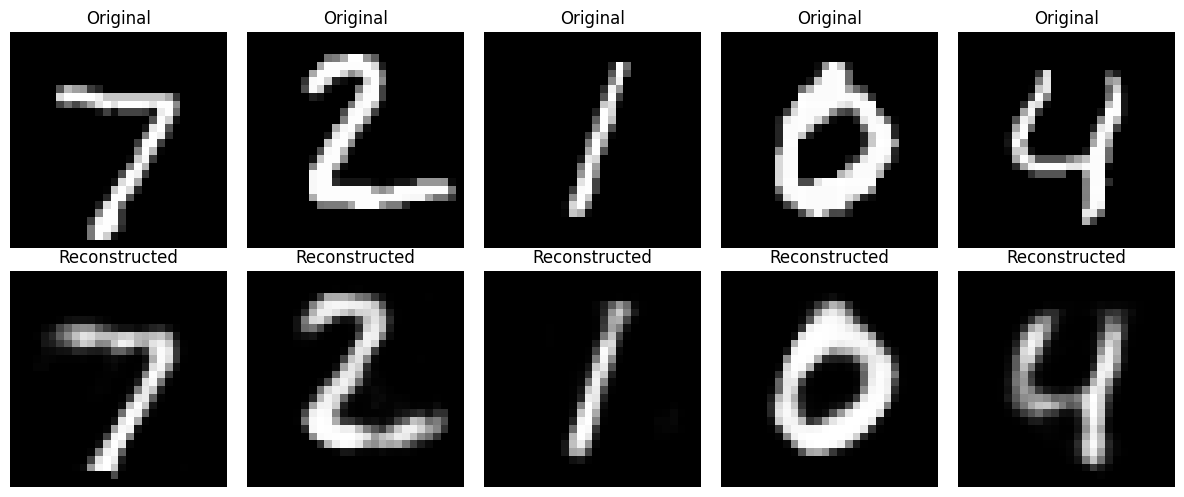

In [20]:
n = 5
plt.figure(figsize=(12,5))
for i in range(n):
    ax = plt.subplot(2, n, i+1)
    plt.imshow(x_test[i], cmap='gray') #Original Image
    plt.title("Original")
    plt.axis("off")

    ax = plt.subplot(2, n, i+1+n)
    plt.imshow(reconstructed_images[i], cmap='gray') #Reconstructed image
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.show()


## ================================================

# MEMORY SIZE COMPARISON

In [25]:
original_image = x_test[0] #original data
compressed_image = compressed_data[0] #compressed data

original_size_bytes = original_image.nbytes
original_size_kb = original_size_bytes / 1024

compressed_size_bytes = compressed_image.nbytes
compressed_size_kb = compressed_size_bytes / 1024

compression_ratio = (original_size_bytes / compressed_size_bytes)

print("\n====================================")
print("MEMORY SIZE COMPARISON")
print("====================================")

print(f"Original Image Shape      : {original_image.shape}")
print(f"Compressed Vector Shape   : {compressed_image.shape}")

print("\n------------------------------------")

print(f"Original Image Size       : {original_size_bytes} Bytes")
print(f"Original Image Size       : {original_size_kb:.4f} KB")

print("\n------------------------------------")

print(f"Compressed Vector Size    : {compressed_size_bytes} Bytes")
print(f"Compressed Vector Size    : {compressed_size_kb:.4f} KB")

print("\n------------------------------------")

print(f"Compression Ratio         : {compression_ratio:.2f}x")

print("====================================")


MEMORY SIZE COMPARISON
Original Image Shape      : (28, 28)
Compressed Vector Shape   : (32,)

------------------------------------
Original Image Size       : 6272 Bytes
Original Image Size       : 6.1250 KB

------------------------------------
Compressed Vector Size    : 128 Bytes
Compressed Vector Size    : 0.1250 KB

------------------------------------
Compression Ratio         : 49.00x


# THE END!